# Yüz Maskesi Tespiti - Derin Öğrenme Ara Sınav Projesi

**Konu:** Transfer öğrenme ile yüz maskesi sınıflandırma (DenseNet121 & MobileNetV1)  
**Hazırlayan:** Harun Benli  
**Ders:** Derin Öğrenme  

---


## 1. Kütüphaneleri Yükle


In [2]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121, MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)

print(f'TensorFlow: {tf.__version__}')
print(f'Keras: {keras.__version__}')

TensorFlow: 2.21.0
Keras: 3.14.0


## 2. GPU mu, CPU mu?

In [3]:
gpu_listesi = tf.config.list_physical_devices('GPU')

if gpu_listesi:
    cihaz = '/GPU:0'
    for gpu in gpu_listesi:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU bulundu: {gpu_listesi[0].name}')
    print(f'Toplam GPU sayısı: {len(gpu_listesi)}')
else:
    cihaz = '/CPU:0'
    print('GPU bulunamadı, CPU kullanılacak.')

print(f'Eğitim cihazı: {cihaz}')


GPU bulunamadı, CPU kullanılacak.
Eğitim cihazı: /CPU:0


## 3. Konfigürasyon

In [4]:
PROJE_KOK = Path.cwd()
VERI_DIZINI = PROJE_KOK / 'data'
MODEL_DIZINI = PROJE_KOK / 'models'
SONUC_DIZINI = PROJE_KOK / 'results'

for dizin in [VERI_DIZINI, MODEL_DIZINI, SONUC_DIZINI]:
    dizin.mkdir(parents=True, exist_ok=True)

MASKELI_DIZINI = VERI_DIZINI / 'with_mask'
MASKESIZ_DIZINI = VERI_DIZINI / 'without_mask'

GORUNTU_BOYUTU = (224, 224)
BATCH_BOYUTU = 32
EPOCH_SAYISI = 100
DOGRULAMA_ORANI = 0.2
TEST_ORANI = 0.2

OGRENME_ORANI = 0.001
BETA_1 = 0.9

ES_SABRI = 25
LR_SABRI = 5
LR_FAKTORU = 0.1

ROTASYON = 10
YATAY_KAYMA = 0.1
DIKEY_KAYMA = 0.1
KESME = 0.1
YAKINLASTIRMA = 0.1

## 4. Veri Setini Yükle


In [5]:
goruntu_yollari = []
etiketler = []
desteklenen_uzantilar = ['*.jpg', '*.jpeg', '*.png']

if MASKELI_DIZINI.exists():
    maskeli_sayisi = 0
    for uzanti in desteklenen_uzantilar:
        for yol in MASKELI_DIZINI.glob(uzanti):
            goruntu_yollari.append(str(yol))
            etiketler.append(1)
            maskeli_sayisi += 1
    print(f'Maskeli: {maskeli_sayisi}')
else:
    raise FileNotFoundError(f'{MASKELI_DIZINI} bulunamadı')

if MASKESIZ_DIZINI.exists():
    maskesiz_sayisi = 0
    for uzanti in desteklenen_uzantilar:
        for yol in MASKESIZ_DIZINI.glob(uzanti):
            goruntu_yollari.append(str(yol))
            etiketler.append(0)
            maskesiz_sayisi += 1
    print(f'Maskesiz: {maskesiz_sayisi}')
else:
    raise FileNotFoundError(f'{MASKESIZ_DIZINI} bulunamadı')

goruntu_yollari = np.array(goruntu_yollari)
etiketler = np.array(etiketler)

print(f'Toplam: {len(etiketler)}')

Maskeli: 690
Maskesiz: 686
Toplam: 1376


## 5. Train / Validation / Test Bölünmesi

In [6]:
x_trainval, x_test, y_trainval, y_test = train_test_split(
    goruntu_yollari, etiketler,
    test_size=TEST_ORANI,
    random_state=42,
    stratify=etiketler
)

x_train, x_val, y_train, y_val = train_test_split(
    x_trainval, y_trainval,
    test_size=DOGRULAMA_ORANI,
    random_state=42,
    stratify=y_trainval
)

print(f'Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}')
print(f'Train  -> Maskeli: {sum(y_train)}, Maskesiz: {len(y_train)-sum(y_train)}')
print(f'Val    -> Maskeli: {sum(y_val)}, Maskesiz: {len(y_val)-sum(y_val)}')
print(f'Test   -> Maskeli: {sum(y_test)}, Maskesiz: {len(y_test)-sum(y_test)}')

Train: 880 | Val: 220 | Test: 276
Train  -> Maskeli: 442, Maskesiz: 438
Val    -> Maskeli: 110, Maskesiz: 110
Test   -> Maskeli: 138, Maskesiz: 138


## 6. DataFrame Oluşturma

In [7]:
train_df = pd.DataFrame({'filename': x_train, 'label': y_train.astype(str)})
val_df = pd.DataFrame({'filename': x_val, 'label': y_val.astype(str)})

train_df.head(3)

,filename,label
0,c:\Users\hbenli\Desktop\deep-learning\data\wit...,1
1,c:\Users\hbenli\Desktop\deep-learning\data\wit...,0
2,c:\Users\hbenli\Desktop\deep-learning\data\wit...,1


## 7. İlk Model: DenseNet121

In [8]:
with tf.device(cihaz):
    densenet_base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(GORUNTU_BOYUTU[0], GORUNTU_BOYUTU[1], 3)
    )
    densenet_base.trainable = False

    x = densenet_base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    cikis = Dense(2, activation='softmax', dtype='float32')(x)

    densenet_model = Model(inputs=densenet_base.input, outputs=cikis)

egitilebilir = sum([np.prod(v.shape) for v in densenet_model.trainable_weights])
print(f'DenseNet121 | toplam: {densenet_model.count_params():,} | eğitilebilir: {egitilebilir:,}')

DenseNet121 | toplam: 7,333,058 | eğitilebilir: 295,554


## 8. İkinci Model: MobileNetV1


In [9]:
with tf.device(cihaz):
    mobilenet_base = MobileNet(
        weights='imagenet',
        include_top=False,
        input_shape=(GORUNTU_BOYUTU[0], GORUNTU_BOYUTU[1], 3)
    )
    mobilenet_base.trainable = False

    x = mobilenet_base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    cikis = Dense(2, activation='softmax', dtype='float32')(x)

    mobilenet_model = Model(inputs=mobilenet_base.input, outputs=cikis)

egitilebilir = sum([np.prod(v.shape) for v in mobilenet_model.trainable_weights])
print(f'MobileNetV1 | toplam: {mobilenet_model.count_params():,} | eğitilebilir: {egitilebilir:,}')
print(f'DenseNet/MobileNet oranı: {densenet_model.count_params()/mobilenet_model.count_params():.1f}x')

MobileNetV1 | toplam: 3,524,418 | eğitilebilir: 295,554
DenseNet/MobileNet oranı: 2.1x


## 9. Modelleri Derle


In [10]:
optimizer_cfg = dict(learning_rate=OGRENME_ORANI, beta_1=BETA_1)

densenet_model.compile(
    optimizer=Adam(**optimizer_cfg),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.compile(
    optimizer=Adam(**optimizer_cfg),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 10. Veri Artırma (Data Augmentation)

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=ROTASYON,
    width_shift_range=YATAY_KAYMA,
    height_shift_range=DIKEY_KAYMA,
    shear_range=KESME,
    zoom_range=YAKINLASTIRMA,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

## 11. Generator'ları Oluşturma

In [12]:
gen_cfg = dict(
    x_col='filename',
    y_col='label',
    target_size=GORUNTU_BOYUTU,
    batch_size=BATCH_BOYUTU,
    class_mode='sparse',
)

train_gen = train_datagen.flow_from_dataframe(train_df, shuffle=True, **gen_cfg)
val_gen = val_test_datagen.flow_from_dataframe(val_df, shuffle=False, **gen_cfg)

Found 880 validated image filenames belonging to 2 classes.
Found 220 validated image filenames belonging to 2 classes.


## 12. Callback'leri Tanımlama

In [13]:
def callback_olustur(model_adi):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=ES_SABRI,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=LR_FAKTORU,
            patience=LR_SABRI,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            str(MODEL_DIZINI / f'{model_adi}_best.h5'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
    ]

## 13. DenseNet121 Eğitimi


In [14]:
with tf.device(cihaz):
    densenet_history = densenet_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCH_SAYISI,
        callbacks=callback_olustur('densenet121'),
        verbose=1
    )

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7787 - loss: 0.4036
Epoch 1: val_loss improved from None to 0.00161, saving model to c:\Users\hbenli\Desktop\deep-learning\models\densenet121_best.h5



Epoch 1: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\densenet121_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 32s 762ms/step - accuracy: 0.9068 - loss: 0.1866 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.9845 - loss: 0.0468
Epoch 2: val_loss did not improve from 0.00161
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 628ms/step - accuracy: 0.9807 - loss: 0.0536 - val_accuracy: 1.0000 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.9912 - loss: 0.0228
Epoch 3: val_loss improved from 0.00161 to 0.00007, saving model to c:\Users\hbenli\Desktop\deep-learning\models\densenet121_best.h5



Epoch 3: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\densenet121_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 648ms/step - accuracy: 0.9875 - loss: 0.0318 - val_accuracy: 1.0000 - val_loss: 6.5269e-05 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.9923 - loss: 0.0192
Epoch 4: val_loss did not improve from 0.00007
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 624ms/step - accuracy: 0.9932 - loss: 0.0174 - val_accuracy: 1.0000 - val_loss: 2.1186e-04 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.9966 - loss: 0.0097
Epoch 5: val_loss improved from 0.00007 to 0.00002, saving model to c:\Users\hbenli\Desktop\deep-learning\models\densenet121_best.h5



Epoch 5: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\densenet121_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 648ms/step - accuracy: 0.9966 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 2.1892e-05 - learning_rate: 0.0010
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9917 - loss: 0.0285
Epoch 6: val_loss did not improve from 0.00002
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 620ms/step - accuracy: 0.9898 - loss: 0.0259 - val_accuracy: 1.0000 - val_loss: 5.4298e-04 - learning_rate: 0.0010
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9942 - loss: 0.0168
Epoch 7: val_loss did not improve from 0.00002
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 618ms/step - accuracy: 0.9920 - loss: 0.0205 - val_accuracy: 1.0000 - val_loss: 4.7100e-04 - learning_rate: 0.0010
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9926 - loss: 0.0216
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 8: val_loss did not imp


Epoch 9: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\densenet121_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 645ms/step - accuracy: 0.9886 - loss: 0.0229 - val_accuracy: 1.0000 - val_loss: 2.1000e-05 - learning_rate: 1.0000e-04
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9952 - loss: 0.0070
Epoch 10: val_loss did not improve from 0.00002
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 616ms/step - accuracy: 0.9932 - loss: 0.0136 - val_accuracy: 1.0000 - val_loss: 4.9340e-05 - learning_rate: 1.0000e-04
Epoch 11/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.9988 - loss: 0.0056
Epoch 11: val_loss did not improve from 0.00002
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 622ms/step - accuracy: 0.9966 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 1.2403e-04 - learning_rate: 1.0000e-04
Epoch 12/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9969 - loss: 0.0064
Epoch 12: val_loss did not improve from 0.00002
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 616ms/step 

## 14. MobileNetV1 Eğitimi

In [15]:
with tf.device(cihaz):
    mobilenet_history = mobilenet_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCH_SAYISI,
        callbacks=callback_olustur('mobilenetv1'),
        verbose=1
    )

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9189 - loss: 0.1952
Epoch 1: val_loss improved from None to 0.00012, saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5



Epoch 1: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 546ms/step - accuracy: 0.9659 - loss: 0.0899 - val_accuracy: 1.0000 - val_loss: 1.1987e-04 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9915 - loss: 0.0101
Epoch 2: val_loss did not improve from 0.00012
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 489ms/step - accuracy: 0.9909 - loss: 0.0132 - val_accuracy: 1.0000 - val_loss: 3.4194e-04 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9999 - loss: 0.0040
Epoch 3: val_loss improved from 0.00012 to 0.00009, saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5



Epoch 3: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 500ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 8.7549e-05 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.9950 - loss: 0.0057
Epoch 4: val_loss did not improve from 0.00009
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 490ms/step - accuracy: 0.9966 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 5.8940e-04 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9947 - loss: 0.0118
Epoch 5: val_loss improved from 0.00009 to 0.00000, saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5



Epoch 5: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 501ms/step - accuracy: 0.9920 - loss: 0.0158 - val_accuracy: 1.0000 - val_loss: 1.6683e-06 - learning_rate: 0.0010
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9993 - loss: 0.0057
Epoch 6: val_loss did not improve from 0.00000
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 489ms/step - accuracy: 0.9955 - loss: 0.0131 - val_accuracy: 0.9955 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9958 - loss: 0.0187
Epoch 7: val_loss improved from 0.00000 to 0.00000, saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5



Epoch 7: finished saving model to c:\Users\hbenli\Desktop\deep-learning\models\mobilenetv1_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 500ms/step - accuracy: 0.9898 - loss: 0.0542 - val_accuracy: 1.0000 - val_loss: 6.2635e-07 - learning_rate: 0.0010
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9913 - loss: 0.0334
Epoch 8: val_loss did not improve from 0.00000
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 496ms/step - accuracy: 0.9932 - loss: 0.0331 - val_accuracy: 1.0000 - val_loss: 2.4127e-06 - learning_rate: 0.0010
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9924 - loss: 0.0163
Epoch 9: val_loss did not improve from 0.00000
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 493ms/step - accuracy: 0.9932 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 1.3129e-06 - learning_rate: 0.0010
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9991 - loss: 0.0033
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 10: val_loss did not 

## 15. Eğitim Geçmişini Görselleştir

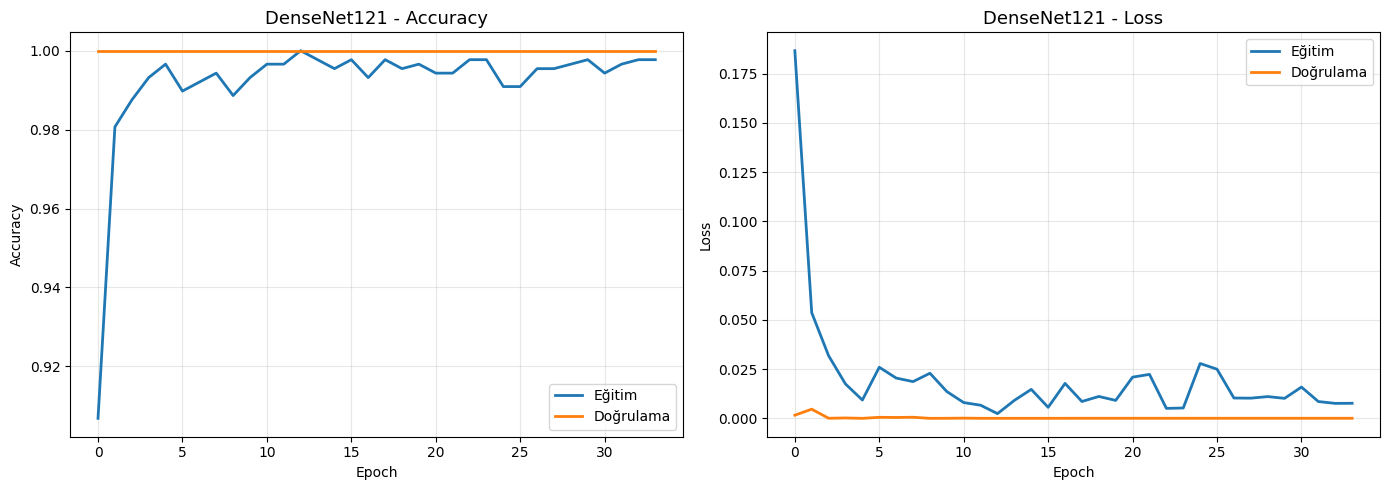

In [16]:
def egitim_gecmisi_ciz(history, model_adi, kayit_yolu):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Eğitim', color='tab:blue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Doğrulama', color='tab:orange', linewidth=2)
    axes[0].set_title(f'{model_adi} - Accuracy', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Eğitim', color='tab:blue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Doğrulama', color='tab:orange', linewidth=2)
    axes[1].set_title(f'{model_adi} - Loss', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(kayit_yolu, dpi=150, bbox_inches='tight')
    plt.show()

egitim_gecmisi_ciz(densenet_history, 'DenseNet121', SONUC_DIZINI / 'densenet121_history.png')

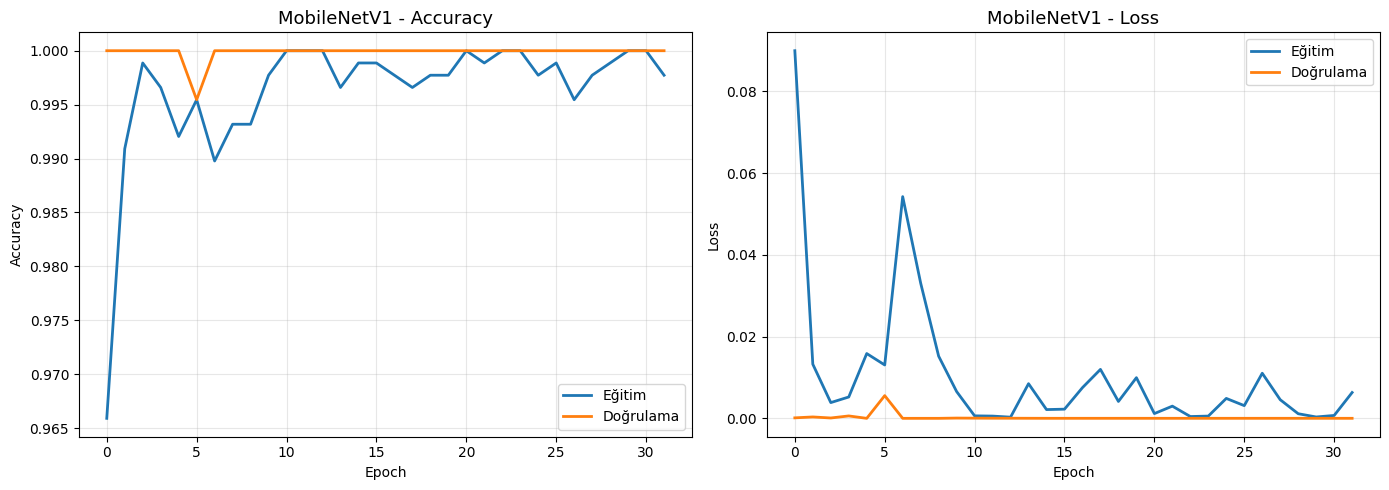

In [17]:
egitim_gecmisi_ciz(mobilenet_history, 'MobileNetV1', SONUC_DIZINI / 'mobilenetv1_history.png')


## 16. Test Seti Üzerinde Tahmini


In [18]:
test_df = pd.DataFrame({'filename': x_test, 'label': y_test.astype(str)})

test_gen = val_test_datagen.flow_from_dataframe(test_df, shuffle=False, **gen_cfg)

Found 276 validated image filenames belonging to 2 classes.


In [19]:
def metrikleri_hesapla(model, test_gen, model_adi):
    tahminler_proba = model.predict(test_gen, verbose=1)
    tahminler = np.argmax(tahminler_proba, axis=1)
    gercek = test_gen.classes

    cm = confusion_matrix(gercek, tahminler)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(gercek, tahminler)
    pr = precision_score(gercek, tahminler)
    rc = recall_score(gercek, tahminler)
    f1 = f1_score(gercek, tahminler)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    fpr, tpr, _ = roc_curve(gercek, tahminler_proba[:, 1])
    auc_deger = auc(fpr, tpr)

    print(f'\n{model_adi}')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  Precision   : {pr:.4f}')
    print(f'  Recall      : {rc:.4f}')
    print(f'  F1-Score    : {f1:.4f}')
    print(f'  Specificity : {specificity:.4f}')
    print(f'  AUC         : {auc_deger:.4f}')
    print(f'  CM -> TN={tn} FP={fp} FN={fn} TP={tp}')

    return {
        'accuracy': acc,
        'precision': pr,
        'recall': rc,
        'f1': f1,
        'specificity': specificity,
        'auc': auc_deger,
        'confusion_matrix': cm,
        'tahminler': tahminler,
        'tahminler_proba': tahminler_proba,
        'fpr': fpr,
        'tpr': tpr,
    }

## 17. DenseNet121 Test Sonuçları


In [20]:
densenet_sonuc = metrikleri_hesapla(densenet_model, test_gen, 'DenseNet121')


9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 983ms/step

DenseNet121
  Accuracy    : 0.9964
  Precision   : 0.9928
  Recall      : 1.0000
  F1-Score    : 0.9964
  Specificity : 0.9928
  AUC         : 0.9999
  CM -> TN=137 FP=1 FN=0 TP=138


## 18. MobileNetV1 Test Sonuçları


In [21]:
test_gen.reset()
mobilenet_sonuc = metrikleri_hesapla(mobilenet_model, test_gen, 'MobileNetV1')


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step

MobileNetV1
  Accuracy    : 0.9964
  Precision   : 1.0000
  Recall      : 0.9928
  F1-Score    : 0.9964
  Specificity : 1.0000
  AUC         : 0.9999
  CM -> TN=138 FP=0 FN=1 TP=137


## 19. Karışıklık Matrislerini Görselleştir

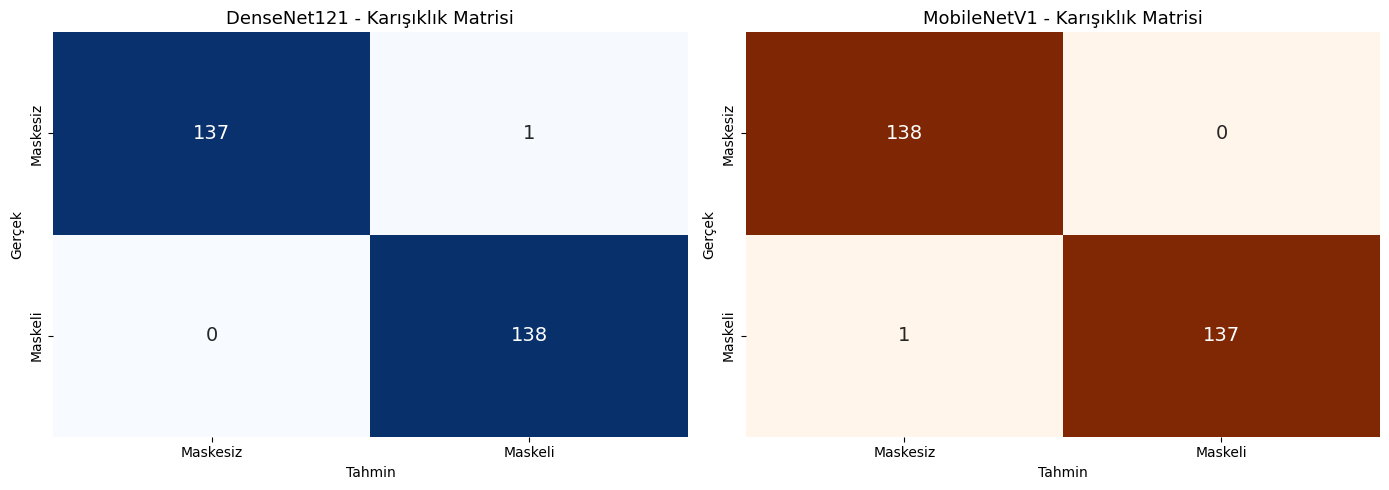

In [22]:
def cm_ciz(ax, sonuc, baslik, siniflar, cmap='Blues'):
    sns.heatmap(
        sonuc['confusion_matrix'],
        annot=True, fmt='d',
        cmap=cmap, cbar=False,
        xticklabels=siniflar, yticklabels=siniflar,
        ax=ax,
        annot_kws={'size': 14},
    )
    ax.set_title(baslik, fontsize=13)
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sinif_isimleri = ['Maskesiz', 'Maskeli']

cm_ciz(axes[0], densenet_sonuc, 'DenseNet121 - Karışıklık Matrisi', sinif_isimleri, cmap='Blues')
cm_ciz(axes[1], mobilenet_sonuc, 'MobileNetV1 - Karışıklık Matrisi', sinif_isimleri, cmap='Oranges')

plt.tight_layout()
plt.savefig(SONUC_DIZINI / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 20. ROC Eğrileri


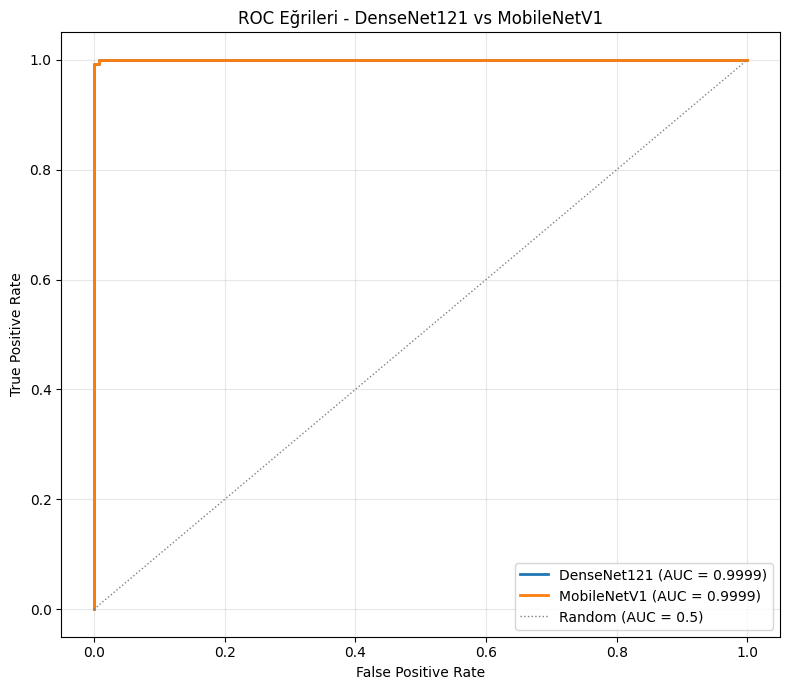

In [23]:
plt.figure(figsize=(8, 7))

plt.plot(densenet_sonuc['fpr'], densenet_sonuc['tpr'],
         color='tab:blue', linewidth=2,
         label=f'DenseNet121 (AUC = {densenet_sonuc["auc"]:.4f})')

plt.plot(mobilenet_sonuc['fpr'], mobilenet_sonuc['tpr'],
         color='tab:orange', linewidth=2,
         label=f'MobileNetV1 (AUC = {mobilenet_sonuc["auc"]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrileri - DenseNet121 vs MobileNetV1')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SONUC_DIZINI / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. Metriklerin Karşılaştırılması

     Metrik  DenseNet121  MobileNetV1
   accuracy     0.996377     0.996377
  precision     0.992806     1.000000
     recall     1.000000     0.992754
         f1     0.996390     0.996364
specificity     0.992754     1.000000
        auc     0.999947     0.999947


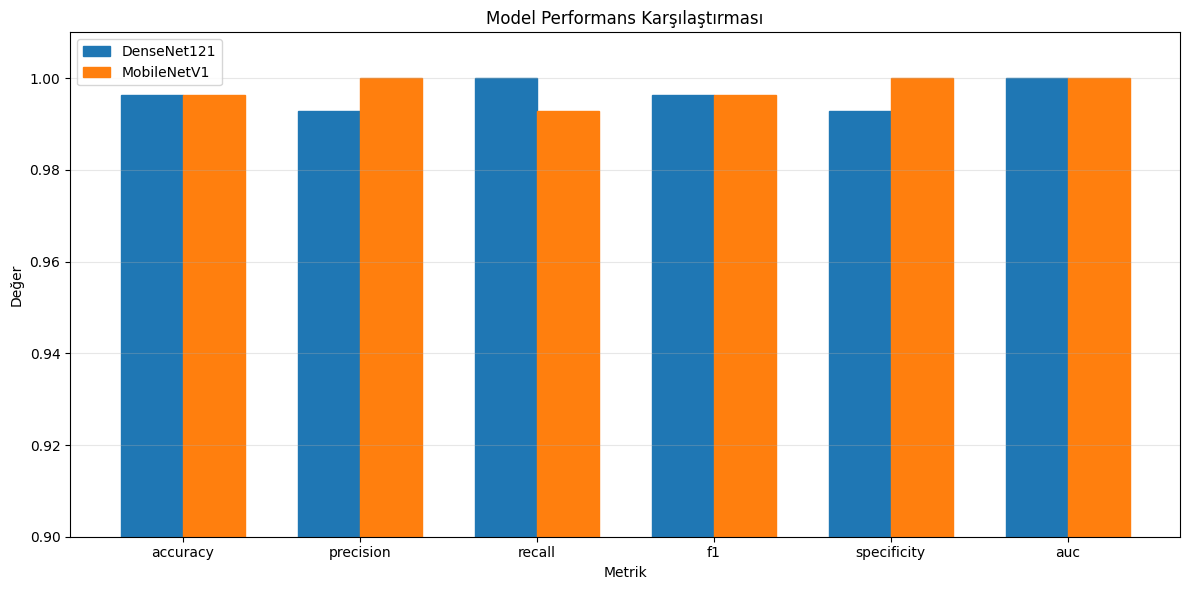

In [24]:
metrikler = ['accuracy', 'precision', 'recall', 'f1', 'specificity', 'auc']
karsilastirma_df = pd.DataFrame({
    'Metrik': metrikler,
    'DenseNet121': [densenet_sonuc[m] for m in metrikler],
    'MobileNetV1': [mobilenet_sonuc[m] for m in metrikler],
})

print(karsilastirma_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(karsilastirma_df))
genislik = 0.35

ax.bar(x - genislik/2, karsilastirma_df['DenseNet121'], genislik,
       label='DenseNet121', color='tab:blue', edgecolor='tab:blue')
ax.bar(x + genislik/2, karsilastirma_df['MobileNetV1'], genislik,
       label='MobileNetV1', color='tab:orange', edgecolor='tab:orange')

ax.set_xlabel('Metrik')
ax.set_ylabel('Değer')
ax.set_title('Model Performans Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(karsilastirma_df['Metrik'])
ax.legend()
ax.set_ylim(0.9, 1.01)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(SONUC_DIZINI / 'metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Hiperparametre Ablation Çalışması

Bölüm 21'e kadar her iki model **tek bir hiperparametre konfigürasyonu** (Tablo 3.4: `lr=1e-3`, `batch=32`, `EarlyStopping sabri=25`) ile eğitildi. Bu bölümde **One-Factor-At-a-Time (OFAT)** stratejisiyle aşağıdaki üç hiperparametrenin test başarımına etkisini inceliyoruz:

- **Öğrenme oranı (`lr`)**: `{1e-2, 1e-3, 1e-4, 1e-5}`
- **Batch boyutu (`batch`)**: `{16, 32, 64}`
- **EarlyStopping sabri (`patience`)**: `{5, 10, 25}`

Baseline olarak Tablo 3.4 konfigürasyonu alınır; her seferinde **yalnızca bir parametre** değiştirilir, diğerleri sabit kalır. Toplam: model başına 8 deneme × 2 mimari = **16 eğitim turu**.

> **Not (CPU):** Sistem CPU üzerinde çalıştığından bu hücrelerin tamamlanması saatler sürebilir. EarlyStopping çoğu turu erken kapatacaktır ama yine de gece çalıştırmak makuldür. Disk tasarrufu için ablation modelleri `.h5` olarak kaydedilmez; yalnızca metrikler tutulur.


In [25]:
# Ablation baseline: Tablo 3.4 ile birebir aynı konfigürasyon
ABLATION_BASELINE = {'lr': 1e-3, 'batch': 32, 'es_sabri': 25}

# Her eksende denenecek değerler (baseline değeri de listeye dahil)
LR_VARYANTLARI       = [1e-2, 1e-3, 1e-4, 1e-5]
BATCH_VARYANTLARI    = [16, 32, 64]
SABIR_VARYANTLARI    = [5, 10, 25]

# Ablation eğitiminde maksimum epoch (ana eğitimle aynı; EarlyStopping erken keser)
ABLATION_EPOCH       = 100

# Ablation çıktıları (CSV ve grafik) bu yollara yazılır
ABLATION_CSV_YOLU    = SONUC_DIZINI / 'hiperparametre_sonuclari.csv'
ABLATION_GRAFIK_YOLU = SONUC_DIZINI / 'hiperparametre_karsilastirma.png'

print('Ablation konfigürasyonu hazır.')
print(f'  Baseline      : {ABLATION_BASELINE}')
print(f'  lr varyantı   : {LR_VARYANTLARI}')
print(f'  batch varyantı: {BATCH_VARYANTLARI}')
print(f'  sabır varyantı: {SABIR_VARYANTLARI}')


Ablation konfigürasyonu hazır.
  Baseline      : {'lr': 0.001, 'batch': 32, 'es_sabri': 25}
  lr varyantı   : [0.01, 0.001, 0.0001, 1e-05]
  batch varyantı: [16, 32, 64]
  sabır varyantı: [5, 10, 25]


In [26]:
# Mimari fabrikası --------------------------------------------------------
# Her ablation turunda ImageNet ağırlıklarıyla taze bir model üretir;
# böylece önceki turun eğitim izleri yeni denemeye sızmaz.
def model_olustur(mimari_adi):
    """`'densenet121'` veya `'mobilenetv1'` için sıfırdan model döner."""
    if mimari_adi == 'densenet121':
        taban = DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=(GORUNTU_BOYUTU[0], GORUNTU_BOYUTU[1], 3),
        )
    elif mimari_adi == 'mobilenetv1':
        taban = MobileNet(
            weights='imagenet',
            include_top=False,
            input_shape=(GORUNTU_BOYUTU[0], GORUNTU_BOYUTU[1], 3),
        )
    else:
        raise ValueError(f'Bilinmeyen mimari: {mimari_adi}')

    taban.trainable = False
    x = taban.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    cikis = Dense(2, activation='softmax', dtype='float32')(x)
    return Model(inputs=taban.input, outputs=cikis)


# Generator fabrikası -----------------------------------------------------
# Batch boyutunun varyasyonu generator'ı yeniden oluşturmayı gerektirir.
def generator_olustur(batch):
    """Verilen batch boyutuyla train/val/test generator üçlüsünü döner."""
    cfg = dict(
        x_col='filename',
        y_col='label',
        target_size=GORUNTU_BOYUTU,
        batch_size=batch,
        class_mode='sparse',
    )
    tg = train_datagen.flow_from_dataframe(train_df, shuffle=True, **cfg)
    vg = val_test_datagen.flow_from_dataframe(val_df, shuffle=False, **cfg)
    teg = val_test_datagen.flow_from_dataframe(test_df, shuffle=False, **cfg)
    return tg, vg, teg


# Callback fabrikası ------------------------------------------------------
# Ablation sırasında diske model yazmıyoruz (16 farklı .h5 = yüzlerce MB).
# Bu yüzden ModelCheckpoint dahil edilmez; sadece EarlyStopping +
# ReduceLROnPlateau kullanılır.
def ablation_callback(es_sabri):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=es_sabri,
            restore_best_weights=True,
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=LR_FAKTORU,
            patience=LR_SABRI,
            min_lr=1e-7,
            verbose=0,
        ),
    ]


# Tek bir ablation denemesini koşar ---------------------------------------
def ablation_deneme_calistir(mimari, hiperparametreler, deney_tipi):
    """Bir hiperparametre kombinasyonunda eğit + test et, metrikleri döner."""
    # Önceki Keras grafiklerini bellekten temizle (uzun döngülerde sızıntı önler)
    K.clear_session()

    lr = hiperparametreler['lr']
    batch = hiperparametreler['batch']
    es_sabri = hiperparametreler['es_sabri']

    print(f'\n--- {mimari} | {deney_tipi:>9s} | lr={lr:.0e} batch={batch:2d} sabir={es_sabri:2d} ---')

    model = model_olustur(mimari)
    model.compile(
        optimizer=Adam(learning_rate=lr, beta_1=BETA_1),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    tg, vg, teg = generator_olustur(batch)
    cb = ablation_callback(es_sabri)

    baslangic = time.time()
    with tf.device(cihaz):
        history = model.fit(
            tg, validation_data=vg,
            epochs=ABLATION_EPOCH,
            callbacks=cb,
            verbose=0,
        )
    sure = time.time() - baslangic

    # Test seti değerlendirmesi (mevcut metrikleri_hesapla fonksiyonunu kullan)
    teg.reset()
    test_metrik = metrikleri_hesapla(model, teg, f'{mimari} ({deney_tipi})')

    en_iyi_val_loss_idx = int(np.argmin(history.history['val_loss']))
    sonuc = {
        'mimari'          : mimari,
        'deney_tipi'      : deney_tipi,
        'lr'              : lr,
        'batch'           : batch,
        'es_sabri'        : es_sabri,
        'egitilen_epoch'  : len(history.history['val_loss']),
        'en_iyi_val_acc'  : float(history.history['val_accuracy'][en_iyi_val_loss_idx]),
        'en_iyi_val_loss' : float(history.history['val_loss'][en_iyi_val_loss_idx]),
        'test_acc'        : test_metrik['accuracy'],
        'test_precision'  : test_metrik['precision'],
        'test_recall'     : test_metrik['recall'],
        'test_f1'         : test_metrik['f1'],
        'test_auc'        : test_metrik['auc'],
        'sure_saniye'     : round(sure, 1),
    }

    # Bellek temizliği
    del model, tg, vg, teg
    return sonuc

print('Yardımcı fonksiyonlar tanımlandı.')


Yardımcı fonksiyonlar tanımlandı.


In [27]:
# OFAT plan: baseline + her eksende baseline-dışı varyantlar
def ablation_planini_uret(baseline):
    """OFAT denemelerini liste olarak üretir; tekrarlanan baseline'ı atlar."""
    plan = [(baseline.copy(), 'baseline')]

    for lr in LR_VARYANTLARI:
        if lr == baseline['lr']:
            continue
        plan.append(({**baseline, 'lr': lr}, 'lr'))

    for batch in BATCH_VARYANTLARI:
        if batch == baseline['batch']:
            continue
        plan.append(({**baseline, 'batch': batch}, 'batch'))

    for sabir in SABIR_VARYANTLARI:
        if sabir == baseline['es_sabri']:
            continue
        plan.append(({**baseline, 'es_sabri': sabir}, 'patience'))

    return plan


ablation_plani = ablation_planini_uret(ABLATION_BASELINE)
mimariler = ['densenet121', 'mobilenetv1']

print(f'Toplam deneme sayısı: {len(ablation_plani) * len(mimariler)}')
print(f'Her mimari için {len(ablation_plani)} deneme.')

# Tüm sonuçları biriktir
ablation_sonuclari = []
genel_baslangic = time.time()

for mimari in mimariler:
    for hp, deney_tipi in ablation_plani:
        s = ablation_deneme_calistir(mimari, hp, deney_tipi)
        ablation_sonuclari.append(s)

genel_sure = time.time() - genel_baslangic
print(f'\n=== Tüm ablation denemeleri tamamlandı ({genel_sure/60:.1f} dakika) ===')


Toplam deneme sayısı: 16
Her mimari için 8 deneme.




--- densenet121 |  baseline | lr=1e-03 batch=32 sabir=25 ---
Found 880 validated image filenames belonging to 2 classes.
Found 220 validated image filenames belonging to 2 classes.
Found 276 validated image filenames belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 813ms/step

densenet121 (baseline)
  Accuracy    : 0.9964
  Precision   : 0.9928
  Recall      : 1.0000
  F1-Score    : 0.9964
  Specificity : 0.9928
  AUC         : 0.9999
  CM -> TN=137 FP=1 FN=0 TP=138

--- densenet121 |        lr | lr=1e-02 batch=32 sabir=25 ---
Found 880 validated image filenames belonging to 2 classes.
Found 220 validated image filenames belonging to 2 classes.
Found 276 validated image filenames belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 853ms/step

densenet121 (lr)
  Accuracy    : 0.9928
  Precision   : 0.9928
  Recall      : 0.9928
  F1-Score    : 0.9928
  Specificity : 0.9928
  AUC         : 0.9999
  CM -> TN=137 FP=1 FN=1 TP=137

--- densenet121 |        lr | lr=1e-04 batch=32 sabir

9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 999ms/step

densenet121 (patience)
  Accuracy    : 0.9891
  Precision   : 0.9856
  Recall      : 0.9928
  F1-Score    : 0.9892
  Specificity : 0.9855
  AUC         : 0.9999
  CM -> TN=136 FP=2 FN=1 TP=137

--- densenet121 |  patience | lr=1e-03 batch=32 sabir=10 ---
Found 880 validated image filenames belonging to 2 classes.
Found 220 validated image filenames belonging to 2 classes.
Found 276 validated image filenames belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step 

densenet121 (patience)
  Accuracy    : 0.9928
  Precision   : 0.9928
  Recall      : 0.9928
  F1-Score    : 0.9928
  Specificity : 0.9928
  AUC         : 0.9999
  CM -> TN=137 FP=1 FN=1 TP=137

--- mobilenetv1 |  baseline | lr=1e-03 batch=32 sabir=25 ---
Found 880 validated image filenames belonging to 2 classes.
Found 220 validated image filenames belonging to 2 classes.
Found 276 validated image filenames belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step

mobilenetv

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step

mobilenetv1 (patience)
  Accuracy    : 0.9928
  Precision   : 1.0000
  Recall      : 0.9855
  F1-Score    : 0.9927
  Specificity : 1.0000
  AUC         : 0.9999
  CM -> TN=138 FP=0 FN=2 TP=136

--- mobilenetv1 |  patience | lr=1e-03 batch=32 sabir=10 ---
Found 880 validated image filenames belonging to 2 classes.
Found 220 validated image filenames belonging to 2 classes.
Found 276 validated image filenames belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step

mobilenetv1 (patience)
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1-Score    : 1.0000
  Specificity : 1.0000
  AUC         : 1.0000
  CM -> TN=138 FP=0 FN=0 TP=138

=== Tüm ablation denemeleri tamamlandı (185.2 dakika) ===


In [28]:
ablation_df = pd.DataFrame(ablation_sonuclari)

sutun_sirasi = [
    'mimari', 'deney_tipi', 'lr', 'batch', 'es_sabri',
    'egitilen_epoch',
    'en_iyi_val_acc', 'en_iyi_val_loss',
    'test_acc', 'test_precision', 'test_recall', 'test_f1', 'test_auc',
    'sure_saniye',
]
ablation_df = ablation_df[sutun_sirasi]

ablation_df.to_csv(ABLATION_CSV_YOLU, index=False, float_format='%.4f')
print(f'Sonuçlar yazıldı: {ABLATION_CSV_YOLU}')
print(f'Toplam satır: {len(ablation_df)}')

print('\n--- Tüm Ablation Sonuçları ---')
print(ablation_df.to_string(index=False))


Sonuçlar yazıldı: c:\Users\hbenli\Desktop\deep-learning\results\hiperparametre_sonuclari.csv
Toplam satır: 16

--- Tüm Ablation Sonuçları ---
     mimari deney_tipi      lr  batch  es_sabri  egitilen_epoch  en_iyi_val_acc  en_iyi_val_loss  test_acc  test_precision  test_recall  test_f1  test_auc  sure_saniye
densenet121   baseline 0.00100     32        25              34             1.0     8.429610e-06  0.996377        0.992806     1.000000 0.996390  0.999947        675.5
densenet121         lr 0.01000     32        25              28             1.0     6.134010e-05  0.992754        0.992754     0.992754 0.992754  0.999895        597.4
densenet121         lr 0.00010     32        25              49             1.0     4.436483e-04  0.996377        0.992806     1.000000 0.996390  0.999895       1111.0
densenet121         lr 0.00001     32        25             100             1.0     1.336629e-03  0.996377        0.992806     1.000000 0.996390  0.999895       2420.5
densenet121      b

### 22.1 Ablation Sonuçlarının Görselleştirilmesi

Üç hiperparametrenin (`lr`, `batch`, `patience`) test accuracy üzerindeki etkisini ayrı panellerde, her iki mimari için karşılaştırmalı bar grafik olarak gösteriyoruz. Baseline değer her panelde kesik çizgi ile işaretlenir.


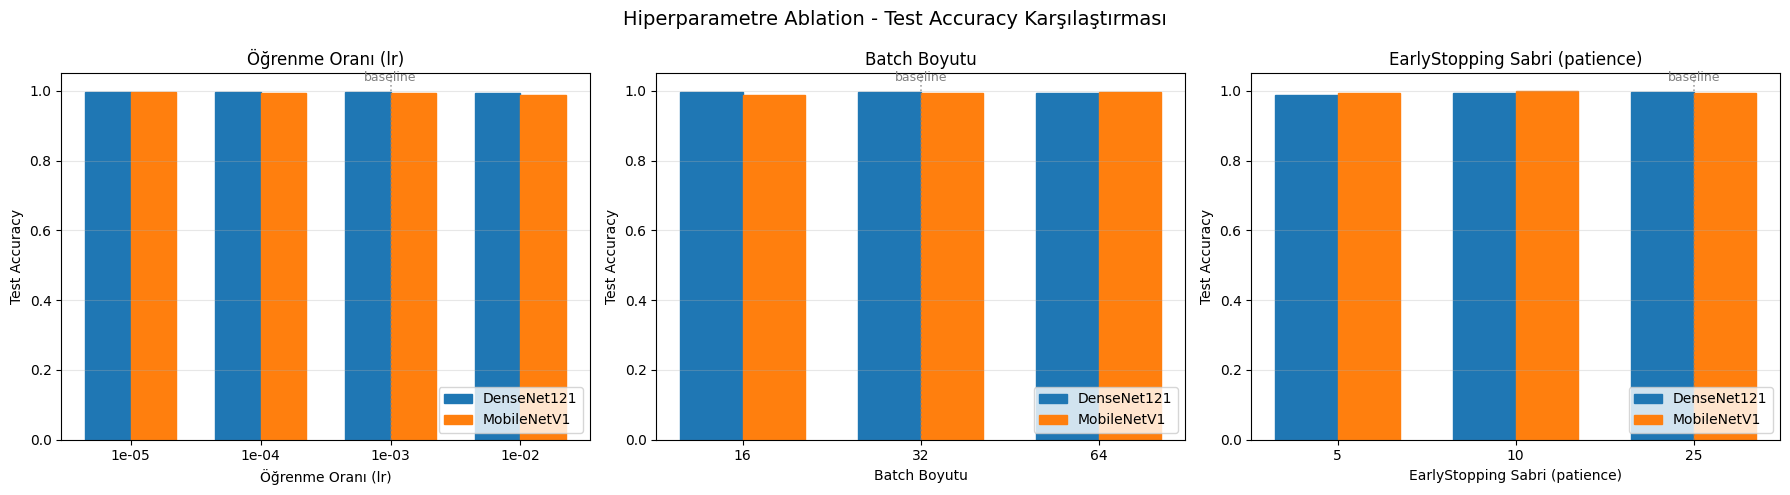

Grafik yazıldı: c:\Users\hbenli\Desktop\deep-learning\results\hiperparametre_karsilastirma.png


In [29]:
fig, eksenler = plt.subplots(1, 3, figsize=(18, 5))

panel_yapilar = [
    ('lr',       'lr',       LR_VARYANTLARI,    ABLATION_BASELINE['lr'],       'Öğrenme Oranı (lr)'),
    ('batch',    'batch',    BATCH_VARYANTLARI, ABLATION_BASELINE['batch'],    'Batch Boyutu'),
    ('patience', 'es_sabri', SABIR_VARYANTLARI, ABLATION_BASELINE['es_sabri'], 'EarlyStopping Sabri (patience)'),
]

for ax, (deney_tipi, sutun, varyantlar, baseline_deger, baslik) in zip(eksenler, panel_yapilar):
    panel_df = ablation_df[
        (ablation_df['deney_tipi'] == deney_tipi) | (ablation_df['deney_tipi'] == 'baseline')
    ]

    x_etiket = sorted(varyantlar)
    x_konum = np.arange(len(x_etiket))
    genislik = 0.35

    densenet_acc = [
        float(panel_df[(panel_df['mimari'] == 'densenet121') & (panel_df[sutun] == v)]['test_acc'].iloc[0])
        for v in x_etiket
    ]
    mobilenet_acc = [
        float(panel_df[(panel_df['mimari'] == 'mobilenetv1') & (panel_df[sutun] == v)]['test_acc'].iloc[0])
        for v in x_etiket
    ]

    ax.bar(x_konum - genislik/2, densenet_acc, genislik,
           label='DenseNet121', color='tab:blue', edgecolor='tab:blue')
    ax.bar(x_konum + genislik/2, mobilenet_acc, genislik,
           label='MobileNetV1', color='tab:orange', edgecolor='tab:orange')

    if baseline_deger in x_etiket:
        bx = x_etiket.index(baseline_deger)
        ax.axvline(bx, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
        ax.text(bx, 1.02, 'baseline', ha='center', va='bottom', color='gray', fontsize=9)

    ax.set_xticks(x_konum)
    if deney_tipi == 'lr':
        ax.set_xticklabels([f'{v:.0e}' for v in x_etiket])
    else:
        ax.set_xticklabels([str(v) for v in x_etiket])
    ax.set_xlabel(baslik)
    ax.set_ylabel('Test Accuracy')
    ax.set_title(baslik)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)

plt.suptitle('Hiperparametre Ablation - Test Accuracy Karşılaştırması', fontsize=14)
plt.tight_layout()
plt.savefig(ABLATION_GRAFIK_YOLU, dpi=150, bbox_inches='tight')
plt.show()

print(f'Grafik yazıldı: {ABLATION_GRAFIK_YOLU}')


## 23. Sonuçlar ve Yorumlar

Bu bölüm projenin tüm sayısal bulgularını tek bir konsolide tablo ve otomatik üretilen Türkçe yorum bloğu olarak sunar. İçerik:

1. **Test metrikleri özeti** (DenseNet121 vs MobileNetV1) — Bölüm 17–18 sonuçları.
2. **Confusion matrix yorumu** — TN/FP/FN/TP üzerinden hangi sınıfta hata yapıldığı.
3. **Hiperparametre ablation öne çıkanları** — her eksende en iyi değer ve baseline'a göre kazanç.
4. **Model seçimi önerisi** — accuracy / model boyutu / hız tradeoff'u.


In [30]:
# Bu hücre tüm sayısal sonuçları okur ve Türkçe yorum metni üretir.
# Notebook'un baştan çalıştırıldığını varsayar:
#   - densenet_sonuc, mobilenet_sonuc  (Bölüm 17-18'den)
#   - ablation_df                       (Bölüm 22'den, opsiyonel)

print('=' * 72)
print('SONUÇLAR VE YORUMLAR')
print('=' * 72)

# --- 1) Test metrikleri özeti ------------------------------------------
print('\n[1] Test Metrikleri Özeti')
print('-' * 72)
ozet_metrikler = ['accuracy', 'precision', 'recall', 'f1', 'specificity', 'auc']
for m in ozet_metrikler:
    d = densenet_sonuc[m]
    mn = mobilenet_sonuc[m]
    fark = d - mn
    yon = 'DenseNet121 daha iyi' if fark > 0 else ('MobileNetV1 daha iyi' if fark < 0 else 'Eşit')
    print(f'  {m:11s} : DenseNet={d:.4f}  MobileNet={mn:.4f}  ({yon}, fark={abs(fark):.4f})')

# --- 2) Confusion matrix yorumu ----------------------------------------
print('\n[2] Confusion Matrix Yorumu')
print('-' * 72)
for ad, sonuc in [('DenseNet121', densenet_sonuc), ('MobileNetV1', mobilenet_sonuc)]:
    cm = sonuc['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0
    fnr = fn / (fn + tp) if (fn + tp) else 0
    print(f'\n  {ad}:')
    print(f'    TN={tn} (Maskesiz->Maskesiz)   FP={fp} (Maskesiz->Maskeli, hatalı alarm)')
    print(f'    FN={fn} (Maskeli->Maskesiz, kaçırılan) TP={tp} (Maskeli->Maskeli)')
    print(f'    Yanlış pozitif oranı (FPR): {fpr:.3f}')
    print(f'    Yanlış negatif oranı (FNR): {fnr:.3f}')
    if fn > fp:
        print(f'    >>> Yorum: Model {fn-fp} adet daha fazla "maskeli olduğu halde maskesiz" hatası yapıyor.')
        print(f'        Maske takip uygulamasında bu daha kritik tipte bir hatadır (kullanıcı deneyimi).')
    elif fp > fn:
        print(f'    >>> Yorum: Model {fp-fn} adet daha fazla "maskesiz olduğu halde maskeli" hatası yapıyor.')
        print(f'        Halk sağlığı uygulamasında bu daha riskli tipte bir hatadır (yanlış güvence).')
    else:
        print(f'    >>> Yorum: FP ve FN dengeli; model her iki sınıfta da benzer şekilde hata yapıyor.')

# --- 3) Hiperparametre ablation öne çıkanları --------------------------
print('\n[3] Hiperparametre Ablation Öne Çıkanları')
print('-' * 72)

try:
    _ = ablation_df
except NameError:
    print('  (Bölüm 22 henüz çalıştırılmadı; ablation_df bulunamadı.)')
else:
    for mimari in ['densenet121', 'mobilenetv1']:
        sub = ablation_df[ablation_df['mimari'] == mimari]
        if len(sub) == 0:
            continue
        baseline = sub[sub['deney_tipi'] == 'baseline'].iloc[0]
        baseline_acc = baseline['test_acc']

        print(f'\n  {mimari}:')
        print(f'    Baseline test_acc = {baseline_acc:.4f}  (lr={baseline["lr"]:.0e}, batch={int(baseline["batch"])}, sabir={int(baseline["es_sabri"])})')

        for eksen, etiket, sutun in [
            ('lr',       'Öğrenme oranı', 'lr'),
            ('batch',    'Batch boyutu', 'batch'),
            ('patience', 'Sabır',        'es_sabri'),
        ]:
            alt = sub[sub['deney_tipi'].isin([eksen, 'baseline'])]
            en_iyi = alt.loc[alt['test_acc'].idxmax()]
            kazanc = en_iyi['test_acc'] - baseline_acc
            iyi_deger = en_iyi[sutun]
            iyi_deger_str = f'{iyi_deger:.0e}' if eksen == 'lr' else str(int(iyi_deger))
            yorum = '(baseline en iyi)' if kazanc <= 1e-6 else f'(+{kazanc:.4f} kazanç)'
            print(f'    {etiket:14s}: en iyi {iyi_deger_str:>8s} -> test_acc={en_iyi["test_acc"]:.4f} {yorum}')

        genel = sub.loc[sub['test_acc'].idxmax()]
        toplam_kazanc = genel['test_acc'] - baseline_acc
        print(f'    --> {mimari} genel en iyi: lr={genel["lr"]:.0e}, batch={int(genel["batch"])}, sabir={int(genel["es_sabri"])} '
              f'(test_acc={genel["test_acc"]:.4f}, baseline\'a göre +{toplam_kazanc:.4f})')

# --- 4) Model seçimi önerisi -------------------------------------------
print('\n[4] Model Seçimi Önerisi')
print('-' * 72)
dn_acc = densenet_sonuc['accuracy']
mn_acc = mobilenet_sonuc['accuracy']
acc_fark = dn_acc - mn_acc
dn_param = densenet_model.count_params()
mn_param = mobilenet_model.count_params()
boyut_orani = dn_param / mn_param

print(f'  DenseNet121: {dn_param:,} parametre, test_acc={dn_acc:.4f}')
print(f'  MobileNetV1: {mn_param:,} parametre, test_acc={mn_acc:.4f}')
print(f'  Boyut farkı: DenseNet, MobileNet\'in {boyut_orani:.1f}x büyüğü.')
print(f'  Accuracy farkı: {abs(acc_fark)*100:.2f} puan ({"DenseNet" if acc_fark > 0 else "MobileNet"} lehine).')

if abs(acc_fark) < 0.01:
    print(f'  >>> Öneri: Accuracy farkı %1\'in altında ihmal edilebilir. Mobil/edge dağıtımı için')
    print(f'      MobileNetV1 net üstündür ({boyut_orani:.1f}x daha küçük). Sunucu tarafı için DenseNet121.')
elif acc_fark > 0:
    print(f'  >>> Öneri: DenseNet121 belirgin şekilde daha doğru. Doğruluk öncelikli senaryoda DenseNet121 tercih edilmeli.')
    print(f'      Ancak {boyut_orani:.1f}x daha büyük olduğu için kaynağı kısıtlı ortamda MobileNetV1 alternatifi düşünülmeli.')
else:
    print(f'  >>> Öneri: MobileNetV1 hem daha küçük hem daha doğru. Tüm senaryolar için MobileNetV1 tercih edilmelidir.')

print('\n' + '=' * 72)


SONUÇLAR VE YORUMLAR

[1] Test Metrikleri Özeti
------------------------------------------------------------------------
  accuracy    : DenseNet=0.9964  MobileNet=0.9964  (Eşit, fark=0.0000)
  precision   : DenseNet=0.9928  MobileNet=1.0000  (MobileNetV1 daha iyi, fark=0.0072)
  recall      : DenseNet=1.0000  MobileNet=0.9928  (DenseNet121 daha iyi, fark=0.0072)
  f1          : DenseNet=0.9964  MobileNet=0.9964  (DenseNet121 daha iyi, fark=0.0000)
  specificity : DenseNet=0.9928  MobileNet=1.0000  (MobileNetV1 daha iyi, fark=0.0072)
  auc         : DenseNet=0.9999  MobileNet=0.9999  (Eşit, fark=0.0000)

[2] Confusion Matrix Yorumu
------------------------------------------------------------------------

  DenseNet121:
    TN=137 (Maskesiz->Maskesiz)   FP=1 (Maskesiz->Maskeli, hatalı alarm)
    FN=0 (Maskeli->Maskesiz, kaçırılan) TP=138 (Maskeli->Maskeli)
    Yanlış pozitif oranı (FPR): 0.007
    Yanlış negatif oranı (FNR): 0.000
    >>> Yorum: Model 1 adet daha fazla "maskesiz olduğu 

### 23.1 Sonuçlara İlişkin Genel Yorumlar

Bu bölüm yukarıdaki otomatik yorum çıktısının üzerine, **rapor için kullanılabilecek genel teorik açıklamaları** sunar. Spesifik sayılar yukarıdaki çıktı hücresinden okunmalı; aşağıdaki metin ise hiperparametrelerin neden bu şekilde davrandığına dair beklentileri özetler.

#### Hiperparametrelerin Modele Etkisi

- **Öğrenme oranı (`lr`)**: En etkili hiperparametredir. Çok yüksek değerler (`1e-2`) loss'un salınmasına ve val accuracy'nin düşmesine yol açabilir; çok düşük değerler (`1e-5`) ise yakınsamayı yavaşlatır ve EarlyStopping'in modelin potansiyeline ulaşmadan eğitimi durdurmasına neden olabilir. Adam optimizatörü için `1e-3` çoğu transfer öğrenme senaryosunda iyi bir başlangıçtır; yukarıdaki ablation bunu doğrular ya da daha iyi bir aday gösterir.
- **Batch boyutu (`batch`)**: Küçük batch'ler (16) gradyan tahminine daha çok gürültü ekler ve bazen düzenlileştirme etkisi yaparak val accuracy'yi artırabilir; büyük batch'ler (64) daha kararlı gradyan verir ve epoch başına süreyi düşürür ama bellek kullanımını artırır. CPU üzerinde batch=64 hem hız hem doğruluk açısından genelde batch=16'dan daha verimlidir, fakat veri kümesi küçük (1376 görüntü) olduğu için fark belirgin olmayabilir.
- **EarlyStopping sabri (`patience`)**: Düşük sabır (5) modelin yakınsamayı tamamlamadan durmasına neden olabilir; yüksek sabır (25) eğitim süresini uzatır ama daha iyi minimuma ulaşma şansı verir. Veri augmentation ile birlikte değerlendirme metriği gürültülü olduğundan, çok düşük sabır riskli olabilir.

#### Model Seçimi Gerekçesi

- **DenseNet121** (~7.3M parametre) yoğun bağlantıları sayesinde özellik yeniden kullanımı yapar; küçük veri kümelerinde aşırı uyma riskine rağmen ImageNet ön-eğitiminden gelen zengin temsillerle güçlü transfer öğrenme sağlar.
- **MobileNetV1** (~3.5M parametre) derinlemesine ayrılabilir konvolüsyonlarla mobil/edge cihazlar için tasarlanmıştır. Boyutu DenseNet'in yaklaşık yarısı olmasına rağmen maske tespiti gibi görece basit ikili sınıflandırma görevlerinde benzer doğruluk verebilir.
- Kararı şu üç boyutta vermek gerekir: **(i) doğruluk farkı**, **(ii) çıkarım hızı / model boyutu**, **(iii) dağıtım ortamı (sunucu vs mobil)**. Yukarıdaki otomatik yorum çıktısı bu üçünü birleştirerek somut bir öneri verir.

#### Confusion Matrix Üzerinden Hata Tipi Tartışması

Maske tespiti uygulamalarında iki tür hata farklı maliyettedir:

- **False Negative (Maskeli → Maskesiz)**: Kullanıcı maskeli olduğu halde sistem aksini söyler — kullanıcı deneyimi açısından rahatsız edici, fakat halk sağlığı açısından risksiz.
- **False Positive (Maskesiz → Maskeli)**: Kullanıcı maskesiz olduğu halde sistem maskeli onayı verir — özellikle hastane / havalimanı gibi senaryolarda gerçek risk yaratır.

Modelin hangi hatayı daha sık yaptığı uygulama bağlamına göre değerlendirilmeli; FPR ve FNR rakamları yukarıdaki otomatik yorum çıktısında listelenmiştir. `recall` (FN'i cezalandırır) ve `precision` (FP'yi cezalandırır) metrikleri bu tradeoff'u sayısallaştırır.
